# DNN Export — Train Final Model & Export Artifacts

Train the winning architecture (Snapshot Attention) from `01_architecture.ipynb` on the full dataset and export production artifacts to `models/`.

**Artifacts exported:**
- `models/dnn_v1.pt` — PyTorch model (full module, loadable by DnnPredictor)
- `models/dnn_scaler_v1.joblib` — fitted StandardScaler for the 11 raw features
- `models/dnn_feature_cols_v1.joblib` — list of 11 raw column names
- `data/optimal_features_dnn.json` — feature config in project-standard format

In [1]:
import json

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

RAW_COLS = [
    "btc_price",
    "elapsed_pct",
    "market_volume",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
]
SEQ_LEN = 50

## 1. Load Data & Build Sequences

In [2]:
rows = []
with open("../../data/latest_features.jsonl") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)
print(f"Snapshots: {len(df):,} | Candles: {df['candle_id'].nunique():,}")

# Build sequences
candle_ids = df["candle_id"].unique()
sequences, targets = [], []
for cid in candle_ids:
    group = df[df["candle_id"] == cid]
    feats = group[RAW_COLS].fillna(0).values.astype(np.float32)
    target = int(group["target"].iloc[0])
    if len(feats) < SEQ_LEN:
        pad = np.tile(feats[0:1], (SEQ_LEN - len(feats), 1))
        feats = np.vstack([pad, feats])
    else:
        feats = feats[-SEQ_LEN:]
    sequences.append(feats)
    targets.append(target)

X_all = np.array(sequences, dtype=np.float32)
y_all = np.array(targets, dtype=np.float32)

# 80/20 time-ordered split
split_idx = int(len(X_all) * 0.8)
X_train_raw, X_test_raw = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# Fit scaler on train data
scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, len(RAW_COLS)))

X_train = scaler.transform(X_train_raw.reshape(-1, len(RAW_COLS))).reshape(X_train_raw.shape)
X_test = scaler.transform(X_test_raw.reshape(-1, len(RAW_COLS))).reshape(X_test_raw.shape)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Snapshots: 245,319 | Candles: 5,187


Train: 4,149 | Test: 1,038


## 2. Define Snapshot Attention Architecture

Winner from `01_architecture.ipynb`. Identical definition so the exported model is self-contained.

In [3]:
class SnapshotAttention(nn.Module):
    """Lightweight self-attention for snapshot sequences."""

    def __init__(self, input_size=11, d_model=64, n_heads=4, n_layers=2, seq_len=50, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_embed
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.head(x)

## 3. Train Final Model

In [4]:
model = SnapshotAttention()
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SnapshotAttention: {params:,} parameters")

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

X_t = torch.tensor(X_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_v = torch.tensor(X_test, dtype=torch.float32)
y_v = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=256, shuffle=True)

best_val_loss = float("inf")
best_state = None
no_improve = 0
PATIENCE = 8

for epoch in range(1, 51):
    model.train()
    for bx, by in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(bx), by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        vl = loss_fn(model(X_v), y_v).item()
        va = ((torch.sigmoid(model(X_v)) >= 0.5).float() == y_v).float().mean().item()

    marker = ""
    if vl < best_val_loss:
        best_val_loss = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
        marker = " *"
    else:
        no_improve += 1

    if epoch % 5 == 0 or marker:
        print(f"  Epoch {epoch:2d}: val_loss={vl:.4f} val_acc={va * 100:.1f}%{marker}")

    scheduler.step()
    if no_improve >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

if best_state:
    model.load_state_dict(best_state)
print(f"\nBest val_loss: {best_val_loss:.4f}")

SnapshotAttention: 70,977 parameters


  Epoch  1: val_loss=0.3287 val_acc=85.5% *


  Epoch  2: val_loss=0.2291 val_acc=90.2% *


  Epoch  3: val_loss=0.1391 val_acc=94.4% *


  Epoch  4: val_loss=0.1120 val_acc=95.7% *


...

  Epoch 11: val_loss=0.0901 val_acc=96.1% *


  Epoch 13: val_loss=0.0872 val_acc=96.3% *


  Epoch 15: val_loss=0.0890 val_acc=96.3%


  Epoch 20: val_loss=0.0906 val_acc=96.2%


  Early stop at epoch 21

Best val_loss: 0.0872


## 4. Evaluate on Test Set

In [5]:
model.eval()
with torch.no_grad():
    logits = model(X_v)
    probs = torch.sigmoid(logits).numpy().flatten()

preds = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, preds)
brier = brier_score_loss(y_test, probs)
f1 = f1_score(y_test, preds, zero_division=0)

print(f"Accuracy: {acc * 100:.1f}%")
print(f"Brier:    {brier:.4f}")
print(f"F1:       {f1 * 100:.1f}%")

# Verify Brier target
assert brier <= 0.17, f"Brier {brier:.4f} exceeds target 0.17!"
print("\nBrier check PASSED (<= 0.17)")

Accuracy: 96.3%
Brier:    0.0250
F1:       96.3%

Brier check PASSED (<= 0.17)


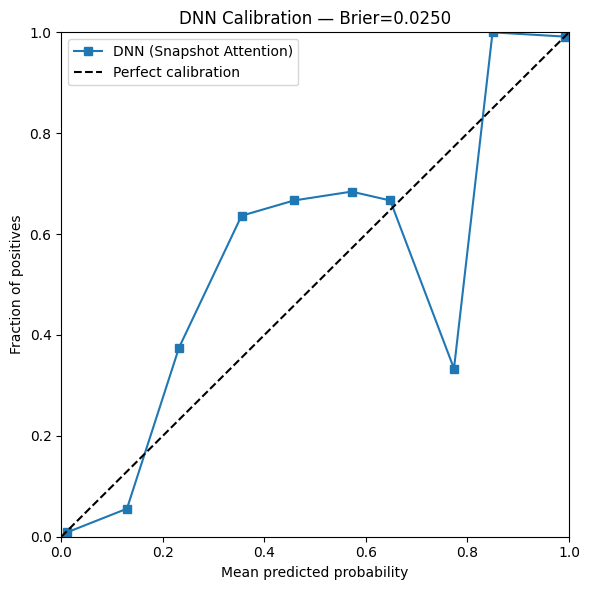

In [6]:
# Calibration curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, "s-", label="DNN (Snapshot Attention)")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title(f"DNN Calibration — Brier={brier:.4f}")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Export Artifacts

In [7]:
import os

MODELS_DIR = "../../models"
DATA_DIR = "../../data"

# 1. Save full model (DnnPredictor uses torch.load with weights_only=False)
model_path = os.path.join(MODELS_DIR, "dnn_v1.pt")
torch.save(model, model_path)
print(f"Model saved: {model_path} ({os.path.getsize(model_path) / 1024:.0f} KB)")

# 2. Save scaler
scaler_path = os.path.join(MODELS_DIR, "dnn_scaler_v1.joblib")
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")

# 3. Save feature columns
feature_cols_path = os.path.join(MODELS_DIR, "dnn_feature_cols_v1.joblib")
joblib.dump(RAW_COLS, feature_cols_path)
print(f"Feature cols saved: {feature_cols_path} ({len(RAW_COLS)} features)")

# 4. Save feature config JSON (project-standard format)
feature_config = {
    "model": "dnn_raw",
    "features": RAW_COLS,
    "n_features": len(RAW_COLS),
    "selection_method": "raw_inputs",
    "architecture": "SnapshotAttention",
    "temporal": True,
    "seq_len": SEQ_LEN,
    "parameters": params,
    "metrics": {
        "accuracy": round(acc, 4),
        "brier": round(brier, 4),
        "f1": round(f1, 4),
    },
}
features_json_path = os.path.join(DATA_DIR, "optimal_features_dnn.json")
with open(features_json_path, "w") as f:
    json.dump(feature_config, f, indent=2)
print(f"Feature config saved: {features_json_path}")

Model saved: ../../models/dnn_v1.pt (291 KB)
Scaler saved: ../../models/dnn_scaler_v1.joblib
Feature cols saved: ../../models/dnn_feature_cols_v1.joblib (11 features)
Feature config saved: ../../data/optimal_features_dnn.json


## 6. Verify Export — Load in DnnPredictor

In [8]:
# Verify the exported model loads correctly in DnnPredictor
import sys

sys.path.insert(0, "../..")
from polybot.adapters.dnn_predictor import DnnPredictor
from polybot.ports.predictor import Predictor

predictor = DnnPredictor(
    model_path=model_path,
    feature_cols_path=feature_cols_path,
    scaler_path=scaler_path,
    temporal=True,
    seq_len=SEQ_LEN,
)

# Verify protocol compliance
assert isinstance(predictor, Predictor), "DnnPredictor does not satisfy Predictor protocol!"

# Test with a sample row
sample_row = {col: float(X_test_raw[0, -1, i]) for i, col in enumerate(RAW_COLS)}
sample_row["candle_id"] = "test_candle"
p = predictor.predict(sample_row)
assert 0.0 <= p <= 1.0, f"Prediction {p} out of [0,1] range!"

print("DnnPredictor loaded and working!")
print(f"Sample prediction: P(UP) = {p:.4f}")
print("Protocol check: isinstance(predictor, Predictor) = True")

DnnPredictor loaded and working!
Sample prediction: P(UP) = 0.9811
Protocol check: isinstance(predictor, Predictor) = True
